# Bengali Sign Language Alphabet Classification

**Model:** MobileNetV2 with Transfer Learning (PyTorch)  
**Dataset:** Bengali Sign Language Dataset (muntakimrafi, Kaggle)  
**Goal:** Classify 38 Bengali sign language alphabet hand gestures, optimised for real-time inference


## Imports & Seed Setup

In [1]:
import os, json, time, random, warnings, ssl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image

# ── macOS SSL fix (certificate verification) ───────────────────────────────────
import certifi
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()
ssl._create_default_https_context = ssl.create_default_context

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from tqdm import tqdm
import onnx

warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ─────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Using device: {DEVICE}')

# ── Paths ───────────────────────────────────────────────────────────────────────
BASE_DIR   = Path('.')
TRAIN_DIR  = BASE_DIR / 'bengali-sign-language-dataset' / 'RESIZED_DATASET'
TEST_DIR   = BASE_DIR / 'bengali-sign-language-dataset' / 'RESIZED_TESTING_DATA'
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'Train dir : {TRAIN_DIR}')
print(f'Test  dir : {TEST_DIR}')
print(f'Output dir: {OUTPUT_DIR}')

Using device: mps
Train dir : bengali-sign-language-dataset/RESIZED_DATASET
Test  dir : bengali-sign-language-dataset/RESIZED_TESTING_DATA
Output dir: output


---
## Step 1 — Dataset Exploration

In [2]:
# ── Bengali alphabet mapping (numeric index → Unicode character) ────────────────
# The 38 classes correspond to Bengali vowels (0-10) then consonants (11-37)
BENGALI_LABELS = [
    'অ', 'আ', 'ই', 'ঈ', 'উ', 'ঊ', 'ঋ', 'এ', 'ঐ', 'ও', 'ঔ',  # vowels  0-10
    'ক', 'খ', 'গ', 'ঘ', 'ঙ', 'চ', 'ছ', 'জ', 'ঝ', 'ঞ',          # consonants 11-20
    'ট', 'ঠ', 'ড', 'ঢ', 'ণ', 'ত', 'থ', 'দ', 'ধ', 'ন',          # consonants 21-30
    'প', 'ফ', 'ব', 'ভ', 'ম', 'য', 'র'                            # consonants 31-37
]

assert len(BENGALI_LABELS) == 38, f'Expected 38 labels, got {len(BENGALI_LABELS)}'

def is_class_dir(p):
    """Return True only for directories whose name is a non-negative integer."""
    return p.is_dir() and p.name.isdigit()

# ── Count images per class ─────────────────────────────────────────────────────
class_folders = sorted(
    (p for p in TRAIN_DIR.iterdir() if is_class_dir(p)),
    key=lambda p: int(p.name)
)
counts      = {p.name: len([f for f in p.iterdir() if not f.name.startswith('.')]) for p in class_folders}
num_classes = len(counts)
total_train = sum(counts.values())

test_class_folders = sorted(
    (p for p in TEST_DIR.iterdir() if is_class_dir(p)),
    key=lambda p: int(p.name)
)
test_counts = {p.name: len([f for f in p.iterdir() if not f.name.startswith('.')]) for p in test_class_folders}
total_test  = sum(test_counts.values())

print(f'\n=== Dataset Summary ===')
print(f'Number of classes     : {num_classes}')
print(f'Total train images    : {total_train}')
print(f'Total test  images    : {total_test}')
print(f'Total images          : {total_train + total_test}')
print(f'Min images per class  : {min(counts.values())}')
print(f'Max images per class  : {max(counts.values())}')
print(f'Mean images per class : {np.mean(list(counts.values())):.1f}')

print(f'\n=== Class → Bengali Character Mapping ===')
for idx, label in enumerate(BENGALI_LABELS):
    cnt = counts.get(str(idx), 0)
    print(f'  Class {idx:2d} ({label}) : {cnt} train images')

# ── Warn small classes ─────────────────────────────────────────────────────────
for idx, cnt in counts.items():
    if cnt < 5:
        print(f'WARNING: class {idx} has only {cnt} images — consider excluding!')

# ── Sample a few images and report dimensions ──────────────────────────────────
print('\n=== Sample Image Dimensions ===')
sample_paths = []
for folder in class_folders[:5]:
    imgs = [f for f in folder.iterdir() if not f.name.startswith('.')]
    if imgs:
        sample_paths.append(imgs[0])

for p in sample_paths:
    img = Image.open(p)
    print(f'  {p.parent.name}/{p.name}: {img.size} mode={img.mode}')


=== Dataset Summary ===
Number of classes     : 38
Total train images    : 11061
Total test  images    : 1520
Total images          : 12581
Min images per class  : 246
Max images per class  : 300
Mean images per class : 291.1

=== Class → Bengali Character Mapping ===
  Class  0 (অ) : 294 train images
  Class  1 (আ) : 294 train images
  Class  2 (ই) : 298 train images
  Class  3 (ঈ) : 286 train images
  Class  4 (উ) : 246 train images
  Class  5 (ঊ) : 294 train images
  Class  6 (ঋ) : 291 train images
  Class  7 (এ) : 289 train images
  Class  8 (ঐ) : 297 train images
  Class  9 (ও) : 292 train images
  Class 10 (ঔ) : 298 train images
  Class 11 (ক) : 291 train images
  Class 12 (খ) : 284 train images
  Class 13 (গ) : 286 train images
  Class 14 (ঘ) : 278 train images
  Class 15 (ঙ) : 294 train images
  Class 16 (চ) : 298 train images
  Class 17 (ছ) : 293 train images
  Class 18 (জ) : 294 train images
  Class 19 (ঝ) : 295 train images
  Class 20 (ঞ) : 293 train images
  Class 21 (ট) :

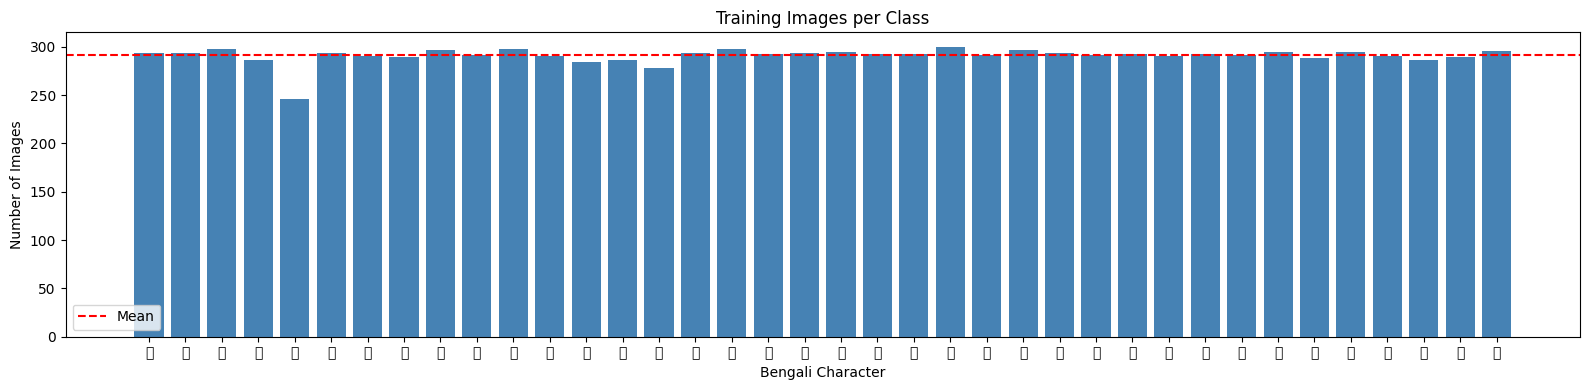

Saved: class_distribution.png


In [3]:
# ── Visualise class distribution ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
bars = ax.bar(range(num_classes), [counts[str(i)] for i in range(num_classes)], color='steelblue')
ax.set_xticks(range(num_classes))
ax.set_xticklabels(BENGALI_LABELS, fontsize=10)
ax.set_xlabel('Bengali Character')
ax.set_ylabel('Number of Images')
ax.set_title('Training Images per Class')
ax.axhline(np.mean(list(counts.values())), color='red', linestyle='--', label='Mean')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=120)
plt.show()
print('Saved: class_distribution.png')

---
## Step 2 — Data Pipeline

In [4]:
# ── ImageNet stats ─────────────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Transforms ─────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomHorizontalFlip(),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

def is_valid_image(path):
    """Skip hidden files like .DS_Store."""
    return not os.path.basename(path).startswith('.')

# ── Load full training dataset ─────────────────────────────────────────────────
full_train_dataset = datasets.ImageFolder(str(TRAIN_DIR), is_valid_file=is_valid_image)
labels_array       = np.array(full_train_dataset.targets)

# ImageFolder sorts class names alphabetically: '0','1','10','11',...,'9'
# We need: folder name (string) → Bengali character (by numeric index)
# Build the correct mapping: internal class index → Bengali label
folder_to_internal = full_train_dataset.class_to_idx  # e.g. {'0': 0, '1': 1, '10': 2, ...}
IDX_TO_LABEL = {}
for folder_name, internal_idx in folder_to_internal.items():
    bengali_char_idx = int(folder_name)               # numeric position in Bengali alphabet
    IDX_TO_LABEL[internal_idx] = BENGALI_LABELS[bengali_char_idx]

print('Sample class_to_idx mapping (folder → internal idx):')
for k in sorted(folder_to_internal.keys(), key=lambda x: int(x))[:5]:
    print(f'  folder "{k}" → internal {folder_to_internal[k]} → label "{IDX_TO_LABEL[folder_to_internal[k]]}"')

# ── Stratified 80% train / 10% val split (from RESIZED_DATASET pool) ───────────
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, temp_idx = next(sss1.split(np.zeros(len(labels_array)), labels_array))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_local_idx, _ = next(sss2.split(np.zeros(len(temp_idx)), labels_array[temp_idx]))
val_idx = temp_idx[val_local_idx]

print(f'\nSplit sizes — Train: {len(train_idx)} | Val: {len(val_idx)} | '
      f'Test (hold-out from RESIZED_TESTING_DATA): {total_test}')

# ── Subset wrapper ─────────────────────────────────────────────────────────────
class SubsetWithTransform(torch.utils.data.Dataset):
    """Wraps a Subset and applies a transform independently."""
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

# Base dataset returns PIL (no transform)
base_dataset_pil = datasets.ImageFolder(str(TRAIN_DIR), transform=None,
                                         is_valid_file=is_valid_image)

train_subset = Subset(base_dataset_pil, train_idx)
val_subset   = Subset(base_dataset_pil, val_idx)

train_ds = SubsetWithTransform(train_subset, train_transform)
val_ds   = SubsetWithTransform(val_subset,   val_transform)
test_ds  = datasets.ImageFolder(str(TEST_DIR), transform=val_transform,
                                 is_valid_file=is_valid_image)

# Build test label mapping (same logic as above)
test_folder_to_internal = test_ds.class_to_idx
TEST_IDX_TO_LABEL = {}
for folder_name, internal_idx in test_folder_to_internal.items():
    TEST_IDX_TO_LABEL[internal_idx] = BENGALI_LABELS[int(folder_name)]

# ── DataLoaders ─────────────────────────────────────────────────────────────────
NUM_WORKERS = 0  # 0 is safest on macOS/MPS
BATCH_SIZE  = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)

print(f'\nDataLoader batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Sample class_to_idx mapping (folder → internal idx):
  folder "0" → internal 0 → label "অ"
  folder "1" → internal 1 → label "আ"
  folder "2" → internal 12 → label "ই"
  folder "3" → internal 23 → label "ঈ"
  folder "4" → internal 32 → label "উ"

Split sizes — Train: 8848 | Val: 1106 | Test (hold-out from RESIZED_TESTING_DATA): 1520

DataLoader batches — Train: 277 | Val: 35 | Test: 48


---
## Step 3 — Model Architecture

In [5]:
NUM_CLASSES = num_classes  # 38

# ── Load MobileNetV2 with pretrained ImageNet weights ───────────────────────────
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# ── Freeze all backbone layers initially ───────────────────────────────────────
for param in model.parameters():
    param.requires_grad = False

# ── Replace classifier head ────────────────────────────────────────────────────
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(1280, NUM_CLASSES),
)

model = model.to(DEVICE)

# ── Count parameters ──────────────────────────────────────────────────────────
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}  (classifier head only)')
print(model.classifier)

Total parameters     : 2,272,550
Trainable parameters : 48,678  (classifier head only)
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=38, bias=True)
)


---
## Step 4 — Training (Two-Phase)

In [6]:
# ── Helpers ────────────────────────────────────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    """Single train or validation epoch. Returns (loss, accuracy)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if is_train:
                optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / total, correct / total


def get_current_lr(optimizer):
    return optimizer.param_groups[0]['lr']


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc  = 0.0
best_val_loss = float('inf')

criterion = nn.CrossEntropyLoss()

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 1 — Head-only training (backbone frozen, 10 epochs)
# ══════════════════════════════════════════════════════════════════════════════
PHASE1_EPOCHS = 10
optimizer_p1  = optim.Adam(model.classifier.parameters(), lr=1e-3)

print('=' * 65)
print(' PHASE 1 — Training classifier head (backbone frozen)')
print('=' * 65)

for epoch in range(1, PHASE1_EPOCHS + 1):
    t_loss, t_acc = run_epoch(model, train_loader, criterion, optimizer_p1)
    v_loss, v_acc = run_epoch(model, val_loader,   criterion)
    lr = get_current_lr(optimizer_p1)

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc  = v_acc
        best_val_loss = v_loss
        torch.save(model.state_dict(), OUTPUT_DIR / 'bengali_sign_model.pth')

    print(f'  Epoch {epoch:2d}/{PHASE1_EPOCHS} | '
          f'Train Loss: {t_loss:.4f} Acc: {t_acc*100:.2f}% | '
          f'Val Loss: {v_loss:.4f} Acc: {v_acc*100:.2f}% | '
          f'LR: {lr:.2e}')

print(f'\nPhase 1 complete. Best val acc: {best_val_acc*100:.2f}%')

 PHASE 1 — Training classifier head (backbone frozen)


  Epoch  1/10 | Train Loss: 2.6131 Acc: 31.44% | Val Loss: 1.8436 Acc: 51.90% | LR: 1.00e-03


  Epoch  2/10 | Train Loss: 1.7360 Acc: 52.17% | Val Loss: 1.5341 Acc: 56.69% | LR: 1.00e-03


  Epoch  3/10 | Train Loss: 1.5020 Acc: 56.61% | Val Loss: 1.3047 Acc: 62.66% | LR: 1.00e-03


  Epoch  4/10 | Train Loss: 1.3911 Acc: 59.29% | Val Loss: 1.2009 Acc: 65.55% | LR: 1.00e-03


...

  Epoch  6/10 | Train Loss: 1.2748 Acc: 61.71% | Val Loss: 1.1904 Acc: 64.92% | LR: 1.00e-03


  Epoch  7/10 | Train Loss: 1.2517 Acc: 61.91% | Val Loss: 1.1334 Acc: 64.83% | LR: 1.00e-03


  Epoch  8/10 | Train Loss: 1.1992 Acc: 63.38% | Val Loss: 1.0984 Acc: 65.73% | LR: 1.00e-03


  Epoch  9/10 | Train Loss: 1.1922 Acc: 64.09% | Val Loss: 1.1016 Acc: 66.55% | LR: 1.00e-03


  Epoch 10/10 | Train Loss: 1.1916 Acc: 63.73% | Val Loss: 1.1008 Acc: 66.27% | LR: 1.00e-03

Phase 1 complete. Best val acc: 66.55%


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Fine-tune last 4-5 feature blocks + head
# ══════════════════════════════════════════════════════════════════════════════
PHASE2_EPOCHS  = 20
EARLY_STOP_PAT = 5   # patience in epochs

# MobileNetV2 features are in model.features (0..18).
# Unfreeze last 5 inverted-residual blocks (indices 14-18).
for i, layer in enumerate(model.features):
    if i >= 14:
        for param in layer.parameters():
            param.requires_grad = True

# Re-enable classifier head params (already trainable but being explicit)
for param in model.classifier.parameters():
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params after unfreezing: {trainable_p2:,}')

optimizer_p2 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler    = optim.lr_scheduler.ReduceLROnPlateau(optimizer_p2, mode='min',
                                                     patience=3, factor=0.5)

no_improve   = 0
prev_lr      = get_current_lr(optimizer_p2)

print('=' * 65)
print(' PHASE 2 — Fine-tuning last 5 feature blocks + head')
print('=' * 65)

for epoch in range(1, PHASE2_EPOCHS + 1):
    t_loss, t_acc = run_epoch(model, train_loader, criterion, optimizer_p2)
    v_loss, v_acc = run_epoch(model, val_loader,   criterion)
    lr = get_current_lr(optimizer_p2)
    scheduler.step(v_loss)
    new_lr = get_current_lr(optimizer_p2)

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    improved = v_acc > best_val_acc
    if improved:
        best_val_acc  = v_acc
        best_val_loss = v_loss
        torch.save(model.state_dict(), OUTPUT_DIR / 'bengali_sign_model.pth')
        no_improve = 0
    else:
        no_improve += 1

    lr_note = f' (LR reduced to {new_lr:.2e})' if new_lr < prev_lr else ''
    prev_lr = new_lr
    marker  = ' ✓ (saved)' if improved else ''
    print(f'  Epoch {epoch:2d}/{PHASE2_EPOCHS} | '
          f'Train Loss: {t_loss:.4f} Acc: {t_acc*100:.2f}% | '
          f'Val Loss: {v_loss:.4f} Acc: {v_acc*100:.2f}% | '
          f'LR: {lr:.2e}{marker}{lr_note}')

    if no_improve >= EARLY_STOP_PAT:
        print(f'  Early stopping triggered at epoch {epoch} (no improvement for {EARLY_STOP_PAT} epochs).')
        break

print(f'\nPhase 2 complete. Best val acc: {best_val_acc*100:.2f}%')

Trainable params after unfreezing: 1,730,022
 PHASE 2 — Fine-tuning last 5 feature blocks + head


  Epoch  1/20 | Train Loss: 0.6887 Acc: 78.42% | Val Loss: 0.4730 Acc: 85.71% | LR: 1.00e-04 ✓ (saved)


  Epoch  2/20 | Train Loss: 0.4480 Acc: 85.33% | Val Loss: 0.4106 Acc: 88.07% | LR: 1.00e-04 ✓ (saved)


  Epoch  3/20 | Train Loss: 0.3592 Acc: 88.36% | Val Loss: 0.3448 Acc: 89.15% | LR: 1.00e-04 ✓ (saved)


  Epoch  4/20 | Train Loss: 0.3016 Acc: 89.98% | Val Loss: 0.3433 Acc: 89.87% | LR: 1.00e-04 ✓ (saved)


...

  Epoch 16/20 | Train Loss: 0.0988 Acc: 96.62% | Val Loss: 0.2266 Acc: 93.58% | LR: 5.00e-05 ✓ (saved)


  Epoch 17/20 | Train Loss: 0.0942 Acc: 96.82% | Val Loss: 0.2384 Acc: 93.67% | LR: 5.00e-05 ✓ (saved)


  Epoch 18/20 | Train Loss: 0.0865 Acc: 97.03% | Val Loss: 0.2465 Acc: 92.86% | LR: 5.00e-05


  Epoch 19/20 | Train Loss: 0.0795 Acc: 97.30% | Val Loss: 0.2551 Acc: 92.95% | LR: 5.00e-05


  Epoch 20/20 | Train Loss: 0.0815 Acc: 97.30% | Val Loss: 0.2334 Acc: 93.58% | LR: 5.00e-05 (LR reduced to 2.50e-05)

Phase 2 complete. Best val acc: 93.67%


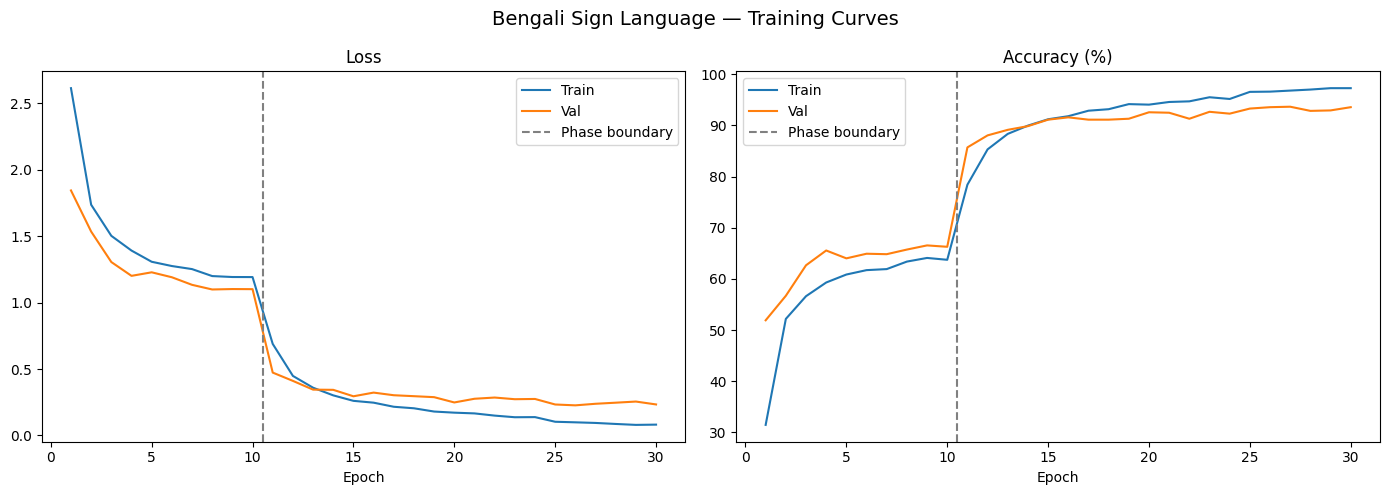

Saved: training_curves.png


In [9]:
# ── Plot training curves ───────────────────────────────────────────────────────
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].axvline(PHASE1_EPOCHS + 0.5, color='gray', linestyle='--', label='Phase boundary')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val')
axes[1].axvline(PHASE1_EPOCHS + 0.5, color='gray', linestyle='--', label='Phase boundary')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

fig.suptitle('Bengali Sign Language — Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=120)
plt.show()
print('Saved: training_curves.png')

---
## Step 5 — Evaluation on Test Set

In [10]:
# ── Load best checkpoint ───────────────────────────────────────────────────────
model.load_state_dict(torch.load(OUTPUT_DIR / 'bengali_sign_model.pth', map_location=DEVICE))
model.eval()
print('Loaded best model checkpoint.')

# ── Run inference on test set ──────────────────────────────────────────────────
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(DEVICE)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1).cpu()
        preds   = probs.argmax(1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Ordered label names for confusion matrix axes
label_names = [TEST_IDX_TO_LABEL[i] for i in range(NUM_CLASSES)]

# ── Metrics ────────────────────────────────────────────────────────────────────
test_acc = (all_preds == all_labels).mean()

# Top-3 accuracy
top3_correct = sum(
    1 for i, label in enumerate(all_labels)
    if label in np.argsort(all_probs[i])[-3:]
)
top3_acc = top3_correct / len(all_labels)

f1 = f1_score(all_labels, all_preds, average='weighted')

print(f'\n=== Test Set Evaluation ===')
print(f'Test Accuracy    : {test_acc*100:.2f}%')
print(f'Top-3 Accuracy   : {top3_acc*100:.2f}%')
print(f'Weighted F1 Score: {f1:.4f}')

Loaded best model checkpoint.


Testing:   0%|          | 0/48 [00:00<?, ?it/s]

Testing:   6%|▋         | 3/48 [00:00<00:02, 21.99it/s]

Testing:  12%|█▎        | 6/48 [00:00<00:01, 23.27it/s]

Testing:  19%|█▉        | 9/48 [00:00<00:01, 23.65it/s]

...

Testing:  88%|████████▊ | 42/48 [00:01<00:00, 24.39it/s]

Testing:  94%|█████████▍| 45/48 [00:01<00:00, 24.34it/s]

Testing: 100%|██████████| 48/48 [00:01<00:00, 24.01it/s]

Testing: 100%|██████████| 48/48 [00:01<00:00, 24.08it/s]


=== Test Set Evaluation ===
Test Accuracy    : 93.42%
Top-3 Accuracy   : 99.14%
Weighted F1 Score: 0.9336


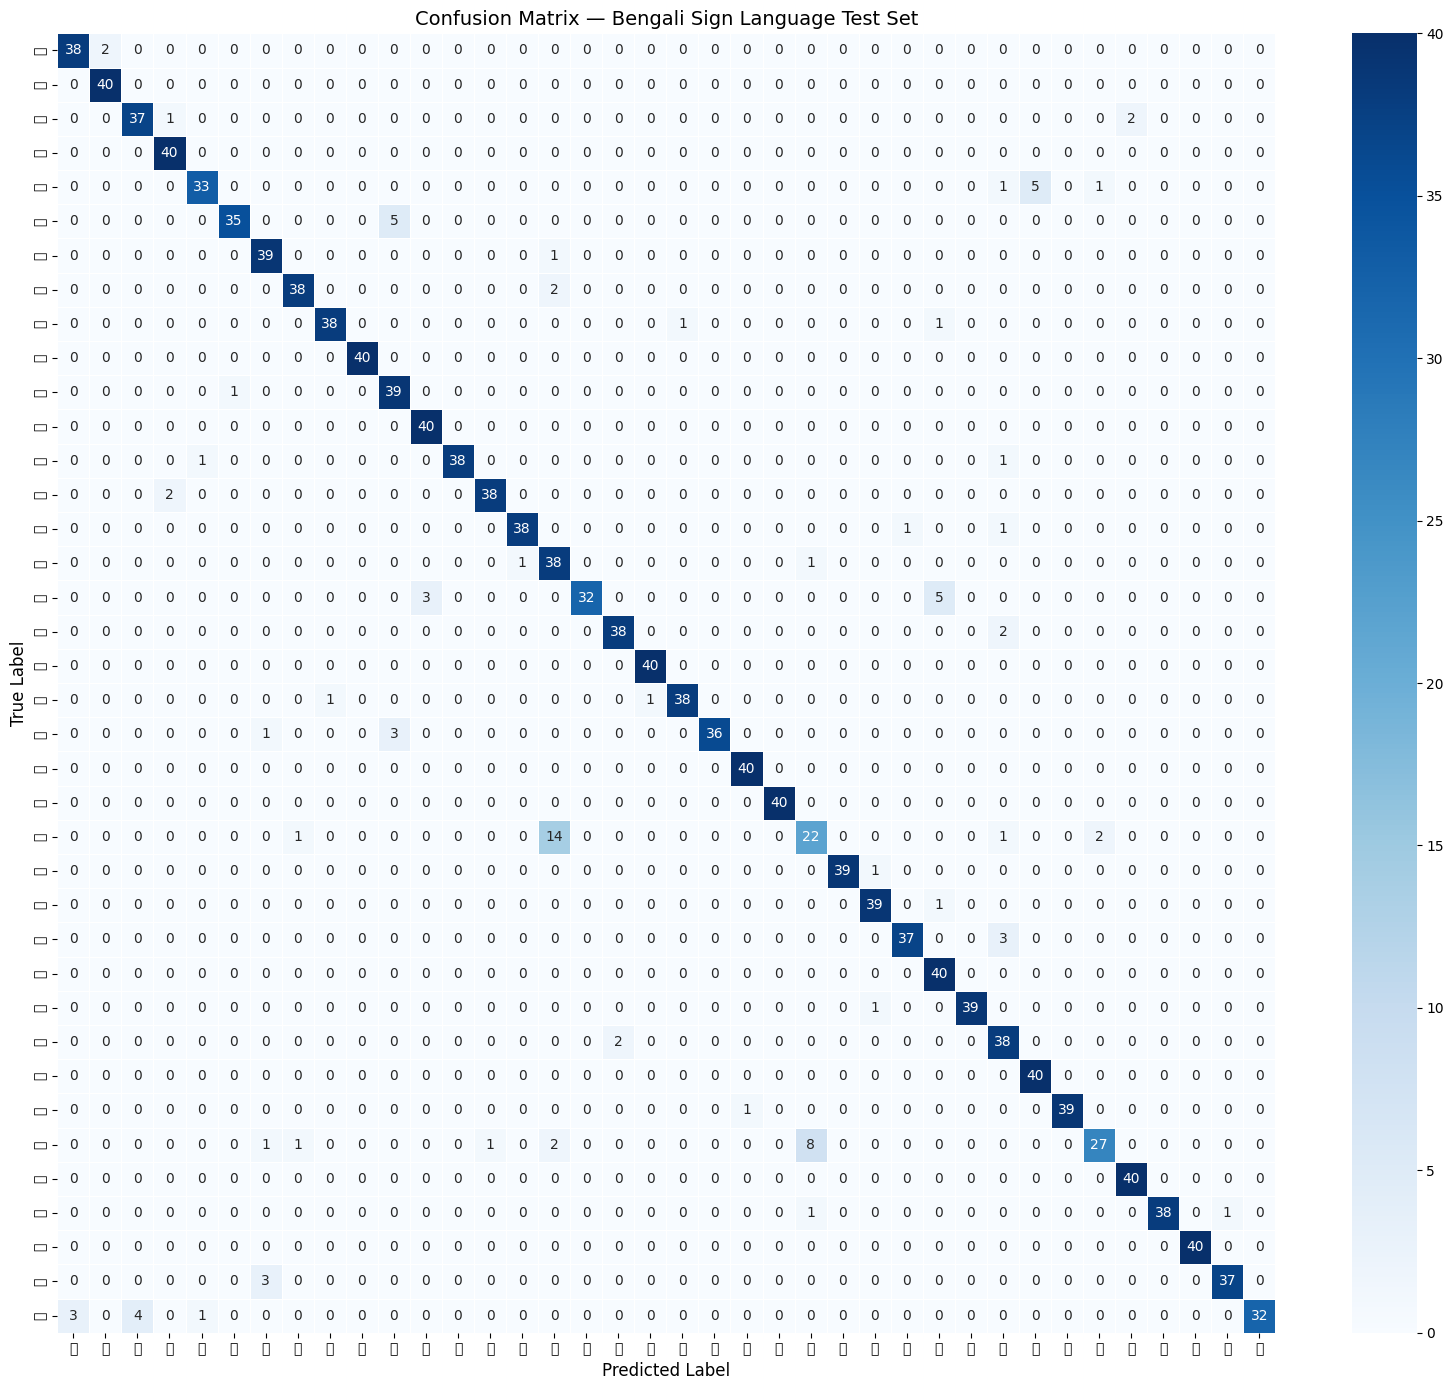

Saved: confusion_matrix.png


In [11]:
# ── Confusion Matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — Bengali Sign Language Test Set', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=120)
plt.show()
print('Saved: confusion_matrix.png')

In [12]:
# ── Top-5 Most Confused Class Pairs ───────────────────────────────────────────
print('\n=== Top-5 Most Confused Class Pairs ===')
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)

confused = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_copy[i, j] > 0:
            confused.append((cm_copy[i, j], i, j))

confused.sort(reverse=True)
for count, true_cls, pred_cls in confused[:5]:
    print(f'  True: {label_names[true_cls]} (class {true_cls}) → '
          f'Predicted: {label_names[pred_cls]} (class {pred_cls}) : {count} errors')


=== Top-5 Most Confused Class Pairs ===
  True: ঈ (class 23) → Predicted: ঠ (class 15) : 14 errors
  True: উ (class 32) → Predicted: ঈ (class 23) : 8 errors
  True: ড (class 16) → Predicted: ব (class 27) : 5 errors
  True: গ (class 5) → Predicted: জ (class 10) : 5 errors
  True: খ (class 4) → Predicted: য (class 30) : 5 errors


In [13]:
# ── Per-class Accuracy (worst → best) ─────────────────────────────────────────
print('\n=== Per-class Accuracy (worst to best) ===')
per_class_acc = []
for cls in range(NUM_CLASSES):
    mask = all_labels == cls
    if mask.sum() > 0:
        acc = (all_preds[mask] == cls).mean()
        per_class_acc.append((acc, cls, label_names[cls]))

per_class_acc.sort(key=lambda x: x[0])
for acc, cls, name in per_class_acc:
    bar = '█' * int(acc * 20) + '░' * (20 - int(acc * 20))
    print(f'  {name} (class {cls:2d}): [{bar}] {acc*100:.1f}%')


=== Per-class Accuracy (worst to best) ===
  ঈ (class 23): [███████████░░░░░░░░░] 55.0%
  উ (class 32): [█████████████░░░░░░░] 67.5%
  ড (class 16): [████████████████░░░░] 80.0%
  ও (class 37): [████████████████░░░░] 80.0%
  খ (class  4): [████████████████░░░░] 82.5%
  গ (class  5): [█████████████████░░░] 87.5%
  থ (class 20): [██████████████████░░] 90.0%
  ঔ (class  2): [██████████████████░░] 92.5%
  ফ (class 26): [██████████████████░░] 92.5%
  ঐ (class 36): [██████████████████░░] 92.5%
  অ (class  0): [███████████████████░] 95.0%
  ঙ (class  7): [███████████████████░] 95.0%
  চ (class  8): [███████████████████░] 95.0%
  ই (class 12): [███████████████████░] 95.0%
  ঞ (class 13): [███████████████████░] 95.0%
  ট (class 14): [███████████████████░] 95.0%
  ঠ (class 15): [███████████████████░] 95.0%
  ঢ (class 17): [███████████████████░] 95.0%
  ত (class 19): [███████████████████░] 95.0%
  ম (class 29): [███████████████████░] 95.0%
  ঋ (class 34): [███████████████████░] 95.0%
  ঘ (class 

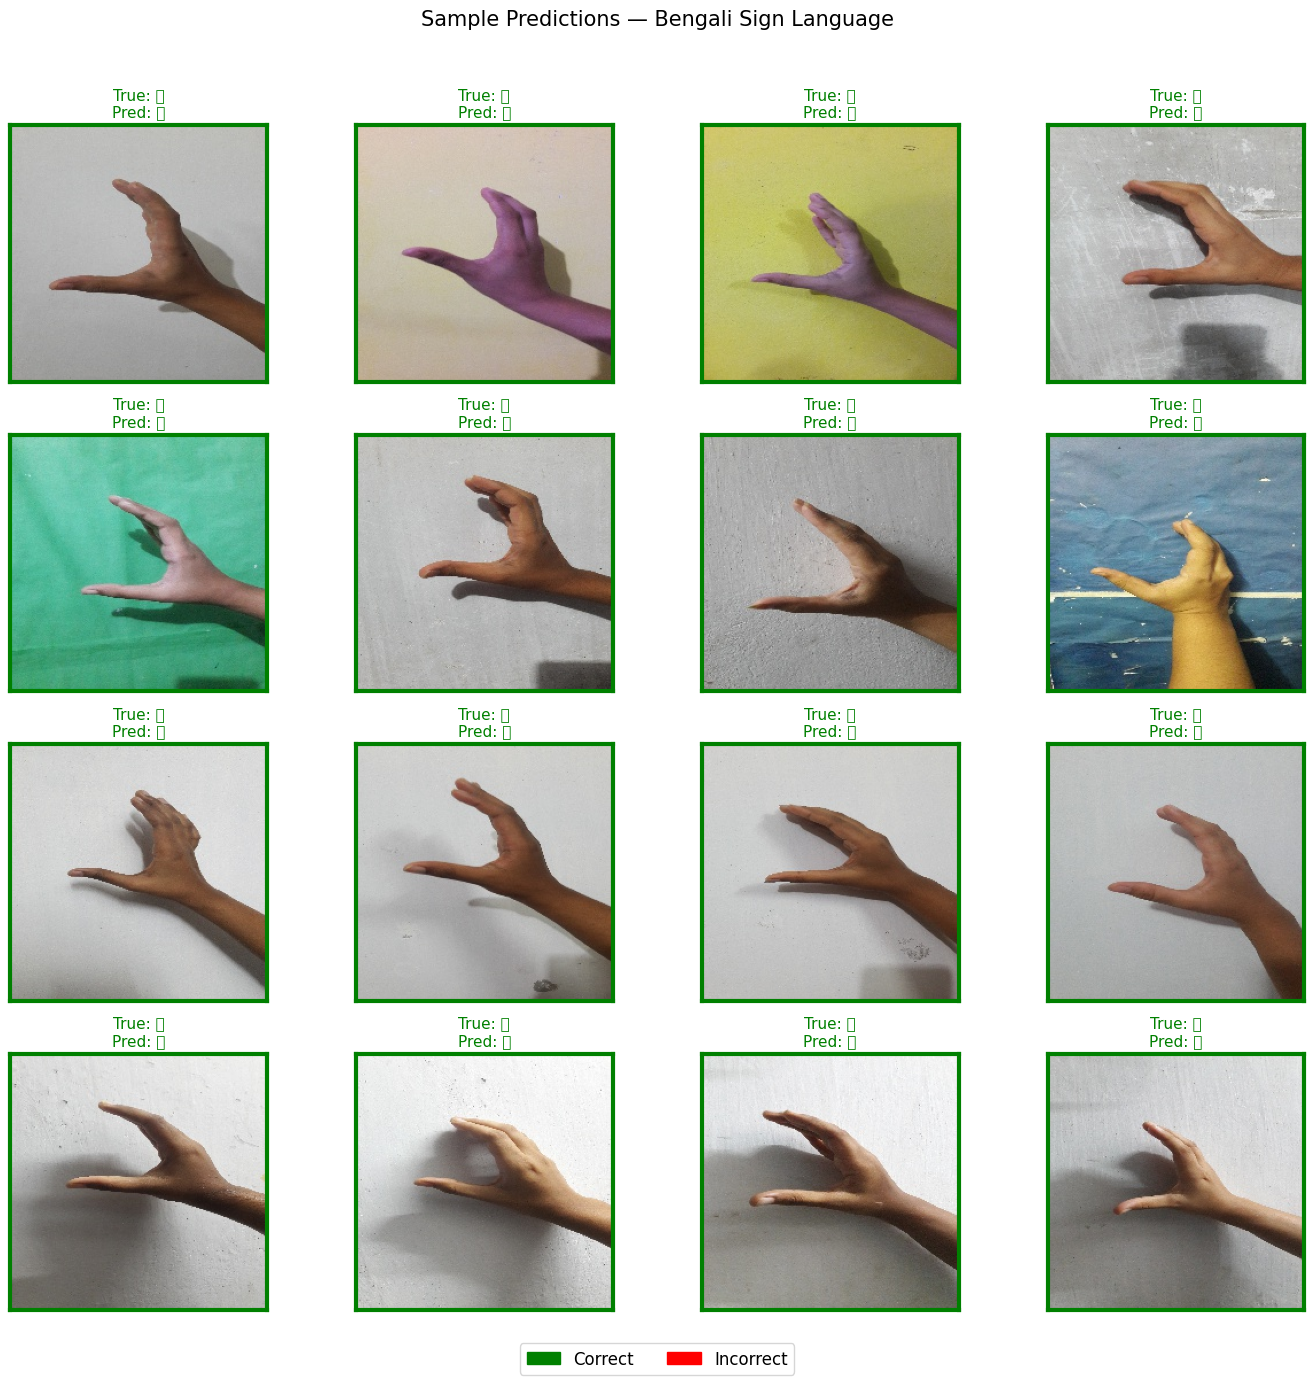

Saved: sample_predictions.png


In [14]:
# ── Sample Predictions Grid (16 images) ───────────────────────────────────────
DENORM_MEAN = torch.tensor(MEAN).view(3, 1, 1)
DENORM_STD  = torch.tensor(STD).view(3, 1, 1)

def denormalize(tensor):
    return (tensor * DENORM_STD + DENORM_MEAN).clamp(0, 1)

# Gather first 16 images from test_loader
sample_imgs, sample_lbls = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        sample_imgs.append(images)
        sample_lbls.append(labels)
        if sum(len(b) for b in sample_imgs) >= 16:
            break

sample_imgs = torch.cat(sample_imgs)[:16]
sample_lbls = torch.cat(sample_lbls)[:16]

with torch.no_grad():
    sample_preds = model(sample_imgs.to(DEVICE)).argmax(1).cpu()

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for i, ax in enumerate(axes.flat):
    img      = denormalize(sample_imgs[i]).permute(1, 2, 0).numpy()
    true_lbl = TEST_IDX_TO_LABEL[sample_lbls[i].item()]
    pred_lbl = TEST_IDX_TO_LABEL[sample_preds[i].item()]
    correct  = true_lbl == pred_lbl
    color    = 'green' if correct else 'red'
    ax.imshow(img)
    ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl}', color=color, fontsize=11)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.set_xticks([])
    ax.set_yticks([])

green_patch = mpatches.Patch(color='green', label='Correct')
red_patch   = mpatches.Patch(color='red',   label='Incorrect')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=12)
fig.suptitle('Sample Predictions — Bengali Sign Language', fontsize=15)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig(OUTPUT_DIR / 'sample_predictions.png', dpi=120)
plt.show()
print('Saved: sample_predictions.png')

---
## Step 6 — Model Export

In [15]:
# ── 1. .pth already saved during training ────────────────────────────────────
pth_path = OUTPUT_DIR / 'bengali_sign_model.pth'
pth_size = pth_path.stat().st_size / (1024 ** 2)
print(f'State dict saved : {pth_path}  ({pth_size:.1f} MB)')

# ── 2. ONNX export ────────────────────────────────────────────────────────────
onnx_path = str(OUTPUT_DIR / 'bengali_sign_model.onnx')

# Build a fresh CPU-only copy of the model by loading the saved state dict.
# This avoids MPS ↔ CPU device mismatches during ONNX tracing.
cpu_model = models.mobilenet_v2()
cpu_model.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(1280, NUM_CLASSES))
cpu_model.load_state_dict(
    torch.load(pth_path, map_location='cpu')
)
cpu_model.eval()

dummy_cpu = torch.randn(1, 3, 224, 224)   # CPU tensor

torch.onnx.export(
    cpu_model,
    dummy_cpu,
    onnx_path,
    dynamo=False,           # legacy TorchScript exporter — no onnxscript dep
    export_params=True,
    opset_version=11,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
)

# Validate
onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)
onnx_size = Path(onnx_path).stat().st_size / (1024 ** 2)
print(f'ONNX model saved : {onnx_path}  ({onnx_size:.1f} MB)')

# ── 3. Class labels JSON ──────────────────────────────────────────────────────
class_labels = {str(i): BENGALI_LABELS[i] for i in range(NUM_CLASSES)}
labels_path  = OUTPUT_DIR / 'class_labels.json'
with open(labels_path, 'w', encoding='utf-8') as f:
    json.dump(class_labels, f, ensure_ascii=False, indent=2)
print(f'Class labels saved: {labels_path}')

# ── 4. CPU inference time benchmark ──────────────────────────────────────────
dummy_bench = torch.randn(1, 3, 224, 224)
N_BENCH = 50
with torch.no_grad():
    _ = cpu_model(dummy_bench)  # warm-up
    t0 = time.time()
    for _ in range(N_BENCH):
        cpu_model(dummy_bench)
    elapsed = (time.time() - t0) / N_BENCH * 1000

print(f'\nEstimated CPU inference time: {elapsed:.1f} ms/image  (avg over {N_BENCH} runs)')

State dict saved : output/bengali_sign_model.pth  (8.9 MB)


ONNX model saved : output/bengali_sign_model.onnx  (8.6 MB)
Class labels saved: output/class_labels.json



Estimated CPU inference time: 40.6 ms/image  (avg over 50 runs)


---
## Step 7 — Summary Report

In [16]:
print()
print('=' * 60)
print('  Bengali Sign Language Model — Training Report')
print('=' * 60)
print(f'Dataset        : {NUM_CLASSES} classes, {total_train + total_test} total images')
print(f'Train/Val/Test : {len(train_idx)} / {len(val_idx)} / {total_test} images')
print(f'Model          : MobileNetV2 (transfer learning)')
print(f'Best val acc   : {best_val_acc*100:.1f}%')
print(f'Test accuracy  : {test_acc*100:.1f}%')
print(f'Top-3 accuracy : {top3_acc*100:.1f}%')
print(f'F1 (weighted)  : {f1:.3f}')
print(f'Model size     : {pth_size:.1f} MB  (.pth)  |  {onnx_size:.1f} MB  (.onnx)')
print(f'CPU infer time : {elapsed:.1f} ms/image')
print(f'Saved files    : bengali_sign_model.pth, bengali_sign_model.onnx,')
print(f'                 class_labels.json, confusion_matrix.png,')
print(f'                 sample_predictions.png, training_curves.png,')
print(f'                 class_distribution.png')
print('=' * 60)


  Bengali Sign Language Model — Training Report
Dataset        : 38 classes, 12581 total images
Train/Val/Test : 8848 / 1106 / 1520 images
Model          : MobileNetV2 (transfer learning)
Best val acc   : 93.7%
Test accuracy  : 93.4%
Top-3 accuracy : 99.1%
F1 (weighted)  : 0.934
Model size     : 8.9 MB  (.pth)  |  8.6 MB  (.onnx)
CPU infer time : 40.6 ms/image
Saved files    : bengali_sign_model.pth, bengali_sign_model.onnx,
                 class_labels.json, confusion_matrix.png,
                 sample_predictions.png, training_curves.png,
                 class_distribution.png
